#### General Imports

# Modified Lava tutorial

Here we modify the STDP tutorial that uses the MNIST to add Reward,
Because the RSTDP tutorial does not use real data.

In [1]:
import os
import typing as ty
import numpy as np

In [2]:
# Import Process level primitives
from lava.magma.core.process.process import AbstractProcess
from lava.magma.core.process.variable import Var
from lava.magma.core.process.ports.ports import InPort, OutPort

In [ ]:
class SpikeInput(AbstractProcess):
    """Reads image data from the MNIST dataset and converts it to spikes.
    The resulting spike rate is proportional to the pixel value."""

    def __init__(self,
                 vth: int,
                 num_images: ty.Optional[int] = 25,
                 num_steps_per_image: ty.Optional[int] = 128,
                 train_epoch : int = 0):
        super().__init__()
        shape = (784,)
        self.spikes_out = OutPort(shape=shape)  # Input spikes to the classifier
        self.label_out = OutPort(shape=(1,))  # Ground truth labels to OutputProc
        self.post_synaptic_trace = OutPort(shape=(10,))  # Post-synaptic trace
        self.num_images = Var(shape=(1,), init=num_images)
        self.num_steps_per_image = Var(shape=(1,), init=num_steps_per_image)
        self.input_img = Var(shape=shape)
        self.ground_truth_label = Var(shape=(1,))
        self.v = Var(shape=shape, init=0)
        self.vth = Var(shape=(1,), init=vth)
        self.train_epoch = Var(shape=(1,), init=train_epoch)

class OutputProcess(AbstractProcess):
    """Process to gather spikes from 10 output LIF neurons and interpret the
    highest spiking rate as the classifier output"""

    def __init__(self, **kwargs):
        super().__init__()
        shape = (10,)
        n_img = kwargs.pop('num_images', 25)
        self.num_images = Var(shape=(1,), init=n_img)
        self.spikes_in = InPort(shape=shape)
        self.label_in = InPort(shape=(1,))
        self.spikes_accum = Var(shape=shape)  # Accumulated spikes for classification
        self.num_steps_per_image = Var(shape=(1,), init=128)
        self.pred_labels = Var(shape=(n_img,))
        self.gt_labels = Var(shape=(n_img,))


#### ProcessModels for Python execution


In [4]:
# Import parent classes for ProcessModels
from lava.magma.core.model.sub.model import AbstractSubProcessModel
from lava.magma.core.model.py.model import PyLoihiProcessModel

# Import ProcessModel ports, data-types
from lava.magma.core.model.py.ports import PyInPort, PyOutPort
from lava.magma.core.model.py.type import LavaPyType

# Import execution protocol and hardware resources
from lava.magma.core.sync.protocols.loihi_protocol import LoihiProtocol
from lava.magma.core.resources import CPU

# Import decorators
from lava.magma.core.decorator import implements, requires

# Import MNIST dataset
from lava.utils.dataloader.mnist import MnistDataset
np.set_printoptions(linewidth=np.inf)

**SpikingInput ProcessModel**

In [ ]:
@implements(proc=SpikeInput, protocol=LoihiProtocol)
@requires(CPU)
class PySpikeInputModel(PyLoihiProcessModel):
    num_images: int = LavaPyType(int, int, precision=32)
    spikes_out: PyOutPort = LavaPyType(PyOutPort.VEC_DENSE, float)
    label_out: PyOutPort = LavaPyType(PyOutPort.VEC_DENSE, np.int32,
                                      precision=32)
    post_synaptic_trace: PyOutPort = LavaPyType(PyOutPort.VEC_DENSE, np.int32, precision=7)

    num_steps_per_image: int = LavaPyType(int, int, precision=32)
    input_img: np.ndarray = LavaPyType(np.ndarray, int, precision=32)
    ground_truth_label: int = LavaPyType(int, int, precision=32)
    v: np.ndarray = LavaPyType(np.ndarray, int, precision=32)
    vth: int = LavaPyType(int, int, precision=32)
    train_epoch: int = LavaPyType(int, int)
    def __init__(self, proc_params):
        super().__init__(proc_params=proc_params)
        self.mnist_dataset = MnistDataset()
        self.curr_img_id = 0
        self.desired_rate = np.zeros((10,128))

    def post_guard(self):
        """Guard function for PostManagement phase.
        """
        if self.time_step % self.num_steps_per_image == 1:
            return True
        return False

    def run_post_mgmt(self):
        """Post-Management phase: executed only when guard function above
        returns True.
        """
        self.desired_rate = np.zeros((10,128))
        img = self.mnist_dataset.images[self.curr_img_id]
        self.ground_truth_label = self.mnist_dataset.labels[self.curr_img_id]
        np.place(self.desired_rate[self.ground_truth_label, :], np.random.rand(self.num_steps_per_image) < 0.8,1)
        for i in range(10):
            if i != self.ground_truth_label:
                np.place(self.desired_rate[i, :], np.random.rand(self.num_steps_per_image) < 0.1,1)

        self.input_img = img.astype(np.int32) - 127
        self.v = np.zeros(self.v.shape)
        self.label_out.send(np.array([self.ground_truth_label]))
        self.curr_img_id += 1

    def run_spk(self):
        """Spiking phase: executed unconditionally at every time-step
        """
        self.v[:] = self.v + self.input_img
        s_out = self.v > self.vth
        self.v[s_out] = 0  # reset voltage to 0 after a spike
        self.spikes_out.send(s_out)
        if self.time_step < self.train_epoch:
            self.post_synaptic_trace.send(self.desired_rate[:,(self.time_step % 128)].astype(np.int32))
        else:
            self.post_synaptic_trace.send(np.zeros((10,)).astype(np.int32))

**OutputProcess ProcessModel**

In [ ]:
@implements(proc=OutputProcess, protocol=LoihiProtocol)
@requires(CPU)
class PyOutputProcessModel(PyLoihiProcessModel):
    label_in: PyInPort = LavaPyType(PyInPort.VEC_DENSE, int, precision=32)
    spikes_in: PyInPort = LavaPyType(PyInPort.VEC_DENSE, bool, precision=1)
    num_images: int = LavaPyType(int, int, precision=32)
    spikes_accum: np.ndarray = LavaPyType(np.ndarray, np.int32, precision=32)
    num_steps_per_image: int = LavaPyType(int, int, precision=32)
    pred_labels: np.ndarray = LavaPyType(np.ndarray, int, precision=32)
    gt_labels: np.ndarray = LavaPyType(np.ndarray, int, precision=32)

    def __init__(self, proc_params):
        super().__init__(proc_params=proc_params)
        self.current_img_id = 0

    def post_guard(self):
        """Guard function for PostManagement phase.
        """
        if self.time_step % self.num_steps_per_image == 0 and \
                self.time_step > 1:
            return True
        return False

    def run_post_mgmt(self):
        """Post-Management phase: executed only when guard function above
        returns True.
        """
        gt_label = self.label_in.recv()
        pred_label = np.argmax(self.spikes_accum)
        self.gt_labels[self.current_img_id] = gt_label
        self.pred_labels[self.current_img_id] = pred_label
        self.current_img_id += 1
        self.spikes_accum = np.zeros_like(self.spikes_accum)

    def run_spk(self):
        """Spiking phase: executed unconditionally at every time-step
        """
        spk_in = self.spikes_in.recv()
        self.spikes_accum = self.spikes_accum + spk_in

In [7]:
num_images = 5
train_percentage = 0.7
num_steps_per_image = 128

In [ ]:
from lava.proc.learning_rules.r_stdp_learning_rule import RewardModulatedSTDP
from lava.proc.learning_rules.stdp_learning_rule import STDPLoihi as STDP

S_STDP = STDP(learning_rate=8,
            A_plus=1,
            A_minus=-5,
            tau_plus=1,
            tau_minus=9,
            t_epoch=int(num_images/train_percentage)*num_steps_per_image
            )

R_STDP = RewardModulatedSTDP(learning_rate=2,
                             A_plus=4,
                             A_minus=-4,
                             pre_trace_decay_tau=8,
                             post_trace_decay_tau=8,
                             pre_trace_kernel_magnitude=10,
                             post_trace_kernel_magnitude=10,
                             eligibility_trace_decay_tau=0.5,
                             t_epoch=100*128
                             )

In [ ]:
from lava.proc.lif.process import LIF, LearningLIF
from lava.proc.dense.process import Dense, LearningDense
import os, sys
from pathlib import Path
sys.path.append('../src')
from utils.RSTDP_neuorn import RSTDPLIF


trained_weights_path=os.path.join('../data/', 'mnist_pretrained.npy')

real_path_trained_wgts = os.path.realpath(trained_weights_path)

wb_list = np.load(real_path_trained_wgts, encoding='latin1', allow_pickle=True)
w0 = wb_list[0].transpose().astype(np.int32)
w1 = wb_list[2].transpose().astype(np.int32)
w2 = wb_list[4].transpose().astype(np.int32)
b1 = wb_list[1].astype(np.int32)
b2 = wb_list[3].astype(np.int32)
b3 = wb_list[5].astype(np.int32)

dense0 = Dense(weights=w0)
lif1 = LIF(shape=(64,), bias_mant=b1, vth=400,
                dv=0, du=4095)
dense1 = Dense(weights=w1)
lif2 = LIF(shape=(64,), bias_mant=b2, vth=350,
                dv=0, du=4095, name='lif2')
dense2 = LearningDense(weights=w2,
                       learning_rule=S_STDP, name='dense2')
# output_lif = RSTDPLIF(shape=(10,), bias_mant=b3,
#                         vth=1, dv=0, du=4095,
#                         learning_rule=R_STDP)
output_lif = LIF(shape=(10,), bias_mant=b3,
                        vth=1, dv=0, du=4095, name='output_lif')
post_conn = Dense(weights=w2)

dense0.a_out.connect(lif1.a_in)
lif1.s_out.connect(dense1.s_in)
dense1.a_out.connect(lif2.a_in)
lif2.s_out.connect(dense2.s_in)
dense2.a_out.connect(output_lif.a_in)

# connection for normal STDP learning
output_lif.s_out.connect(dense2.s_in_bap)
# output_lif.s_out_y1.connect(dense2.s_in_y1)
# output_lif.s_out_y2.connect(dense2.s_in_y2)


#### Connecting Processes

In [10]:


# Create Process instances
spike_input = SpikeInput(vth=1,
                         num_images=num_images,
                         num_steps_per_image=num_steps_per_image,
                         train_epoch=int(num_images*train_percentage)*num_steps_per_image)

output_proc = OutputProcess(num_images=num_images)

# Connect Processes
spike_input.spikes_out.connect(dense0.s_in)
output_lif.s_out.connect(output_proc.spikes_in)

# Connect Input directly to Output for ground truth labels
spike_input.label_out.connect(output_proc.label_in)
#spike_input.post_synaptic_trace.connect(output_lif.a_in)
##post_conn.a_out.connect(output_lif.a_in)
# spike_input.post_synaptic_trace.connect(output_lif.a_third_factor_in)


In [ ]:
from lava.proc.monitor.process import Monitor

pre_monitor = Monitor()
post_monitor = Monitor()

pre_monitor.probe(lif2.s_out,num_images*num_steps_per_image)
post_monitor.probe(output_lif.s_out, num_images*num_steps_per_image)

In [ ]:
from lava.magma.core.run_conditions import RunSteps
from lava.magma.core.run_configs import Loihi2SimCfg

# Loop over all images
for img_id in range(num_images):
    print(f"\rCurrent image: {img_id+1}", end="")

    # Run each image-inference for fixed number of steps
    output_proc.run(
        condition=RunSteps(num_steps=num_steps_per_image),
        run_cfg=Loihi2SimCfg(select_sub_proc_model=True,
                             select_tag='fixed_pt'))

    # Reset internal neural state of LIF neurons
    lif1.v.set(np.zeros((64,), dtype=np.int32))
    lif1.u.set(np.zeros((64,), dtype=np.int32))
    lif2.v.set(np.zeros((64,), dtype=np.int32))
    lif2.u.set(np.zeros((64,), dtype=np.int32))
    output_lif.v.set(np.zeros((10,), dtype=np.int32))
    output_lif.u.set(np.zeros((10,), dtype=np.int32))

# Gather ground truth and predictions before stopping exec
ground_truth = output_proc.gt_labels.get().astype(np.int32)
predictions = output_proc.pred_labels.get().astype(np.int32)

pre_spike = pre_monitor.get_data()['lif2']['s_out']
post_spike = post_monitor.get_data()['output_lif']['s_out']

# Stop the execution
output_proc.stop()

accuracy = np.sum(ground_truth==predictions)/ground_truth.size * 100
training_accuracy = np.sum(ground_truth[:int(num_images*train_percentage)]==predictions[:int(num_images*train_percentage)])/int(num_images*train_percentage) * 100
val_accuracy = np.sum(ground_truth[int(num_images*train_percentage):]==predictions[int(num_images*train_percentage):])/int(num_images*(1-train_percentage)) * 100
print(f"\nGround truth: {ground_truth}\n"
      f"Predictions : {predictions}\n"
      f"Complete accuracy : {accuracy}\n"
      f"Training Accuracy : {training_accuracy}\n"
      f"Validation Accuracy : {val_accuracy}")

Current image: 5
Ground truth: [5 0 4 1 9]
Predictions : [3 0 4 1 4]
Complete accuracy : 60.0
Training Accuracy : 66.66666666666666
Validation Accuracy : 100.0


In [ ]:
import matplotlib.pyplot as plt

def create_raster_plot_subplot(data1, data2, name1=None, name2=None, figsize=None):
    """
    Creates raster plots for the provided data side by side.

    Parameters:
    data1 (np.ndarray): A 2D array where the first dimension represents channels
                        and the second dimension represents timesteps.
    data2 (np.ndarray): A 2D array where the first dimension represents channels
                        and the second dimension represents timesteps.
    """
    if figsize is None:
        channels1, timesteps1 = data1.shape
        channels2, timesteps2 = data2.shape
        x_size = int(max(timesteps1, timesteps2) / 1.5  )
        y_size = max(channels1, channels2) / 20 if max(channels1, channels2) > 100 else max(channels1, channels2) / 2
        figsize = (x_size, y_size)
    else:
        figsize = figsize

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    for channel in range(data1.shape[0]):
        spike_times = np.where(data1[channel])[0]
        axs[0].vlines(spike_times, channel + 0.5, channel + 1.5)

    for channel in range(data2.shape[0]):
        spike_times = np.where(data2[channel])[0]
        axs[1].vlines(spike_times, channel + 0.5, channel + 1.5)

    if name1:
        axs[0].set_title(f"{name1} Raster Plot")
    else:
        axs[0].set_title('Raster Plot 1')

    if name2:
        axs[1].set_title(f"{name2} Raster Plot")
    else:
        axs[1].set_title('Raster Plot 2')

    for ax in axs:
        ax.set_yticks(np.arange(0, max(data1.shape[0], data2.shape[0]) + 1), [f'N {i}' for i in range(0, max(data1.shape[0], data2.shape[0]) + 1)])
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Channels')
        ax.set_ylim(0, max(data1.shape[0], data2.shape[0]))
        ax.set_xlim(0, max(data1.shape[1], data2.shape[1]))
        ax.set_xticks(ticks=np.arange(max(data1.shape[1], data2.shape[1])), labels=np.arange(max(data1.shape[1], data2.shape[1])))
        ax.grid(axis='x', color='black', linestyle='--', linewidth=0.3)

    plt.show()

def create_raster_plot(data, name=None, figsize=None):
    plt.clf()
    if figsize is None:
        channels, timesteps = data.shape
        x_size = timesteps / 2
        y_size = channels / 10 if channels > 100 else channels
        figsize = (x_size, y_size)
    else:
        figsize = figsize

    plt.figure(figsize=figsize)
    print(data.shape)
    for channel in range(data.shape[0]):
        spike_times = np.where(data[channel])[0]
        plt.vlines(spike_times, channel + 0.5, channel + 1.5)

    if name:
        plt.title(f"{name} Raster Plot")
    else:
        plt.title('Raster Plot')

    plt.yticks(np.arange(0, data.shape[0] + 1), [f'N {i}' for i in range(0, data.shape[0]+1)])
    plt.xlabel('Time (ms)')
    plt.ylabel('Channels')
    plt.ylim(0, data.shape[0])
    plt.xlim(0, data.shape[1])
    plt.xticks(ticks=np.arange(data.shape[1]), labels=np.arange(data.shape[1]))
    plt.grid(axis='x', color='black', linestyle='--', linewidth=0.2)
    plt.show()


In [14]:
print(f"pre spike shape: {pre_spike.shape}")
print(f"post spike shape: {post_spike.shape}")

pre spike shape: (640, 64)
post spike shape: (640, 10)


(64, 640)


<Figure size 640x480 with 0 Axes>

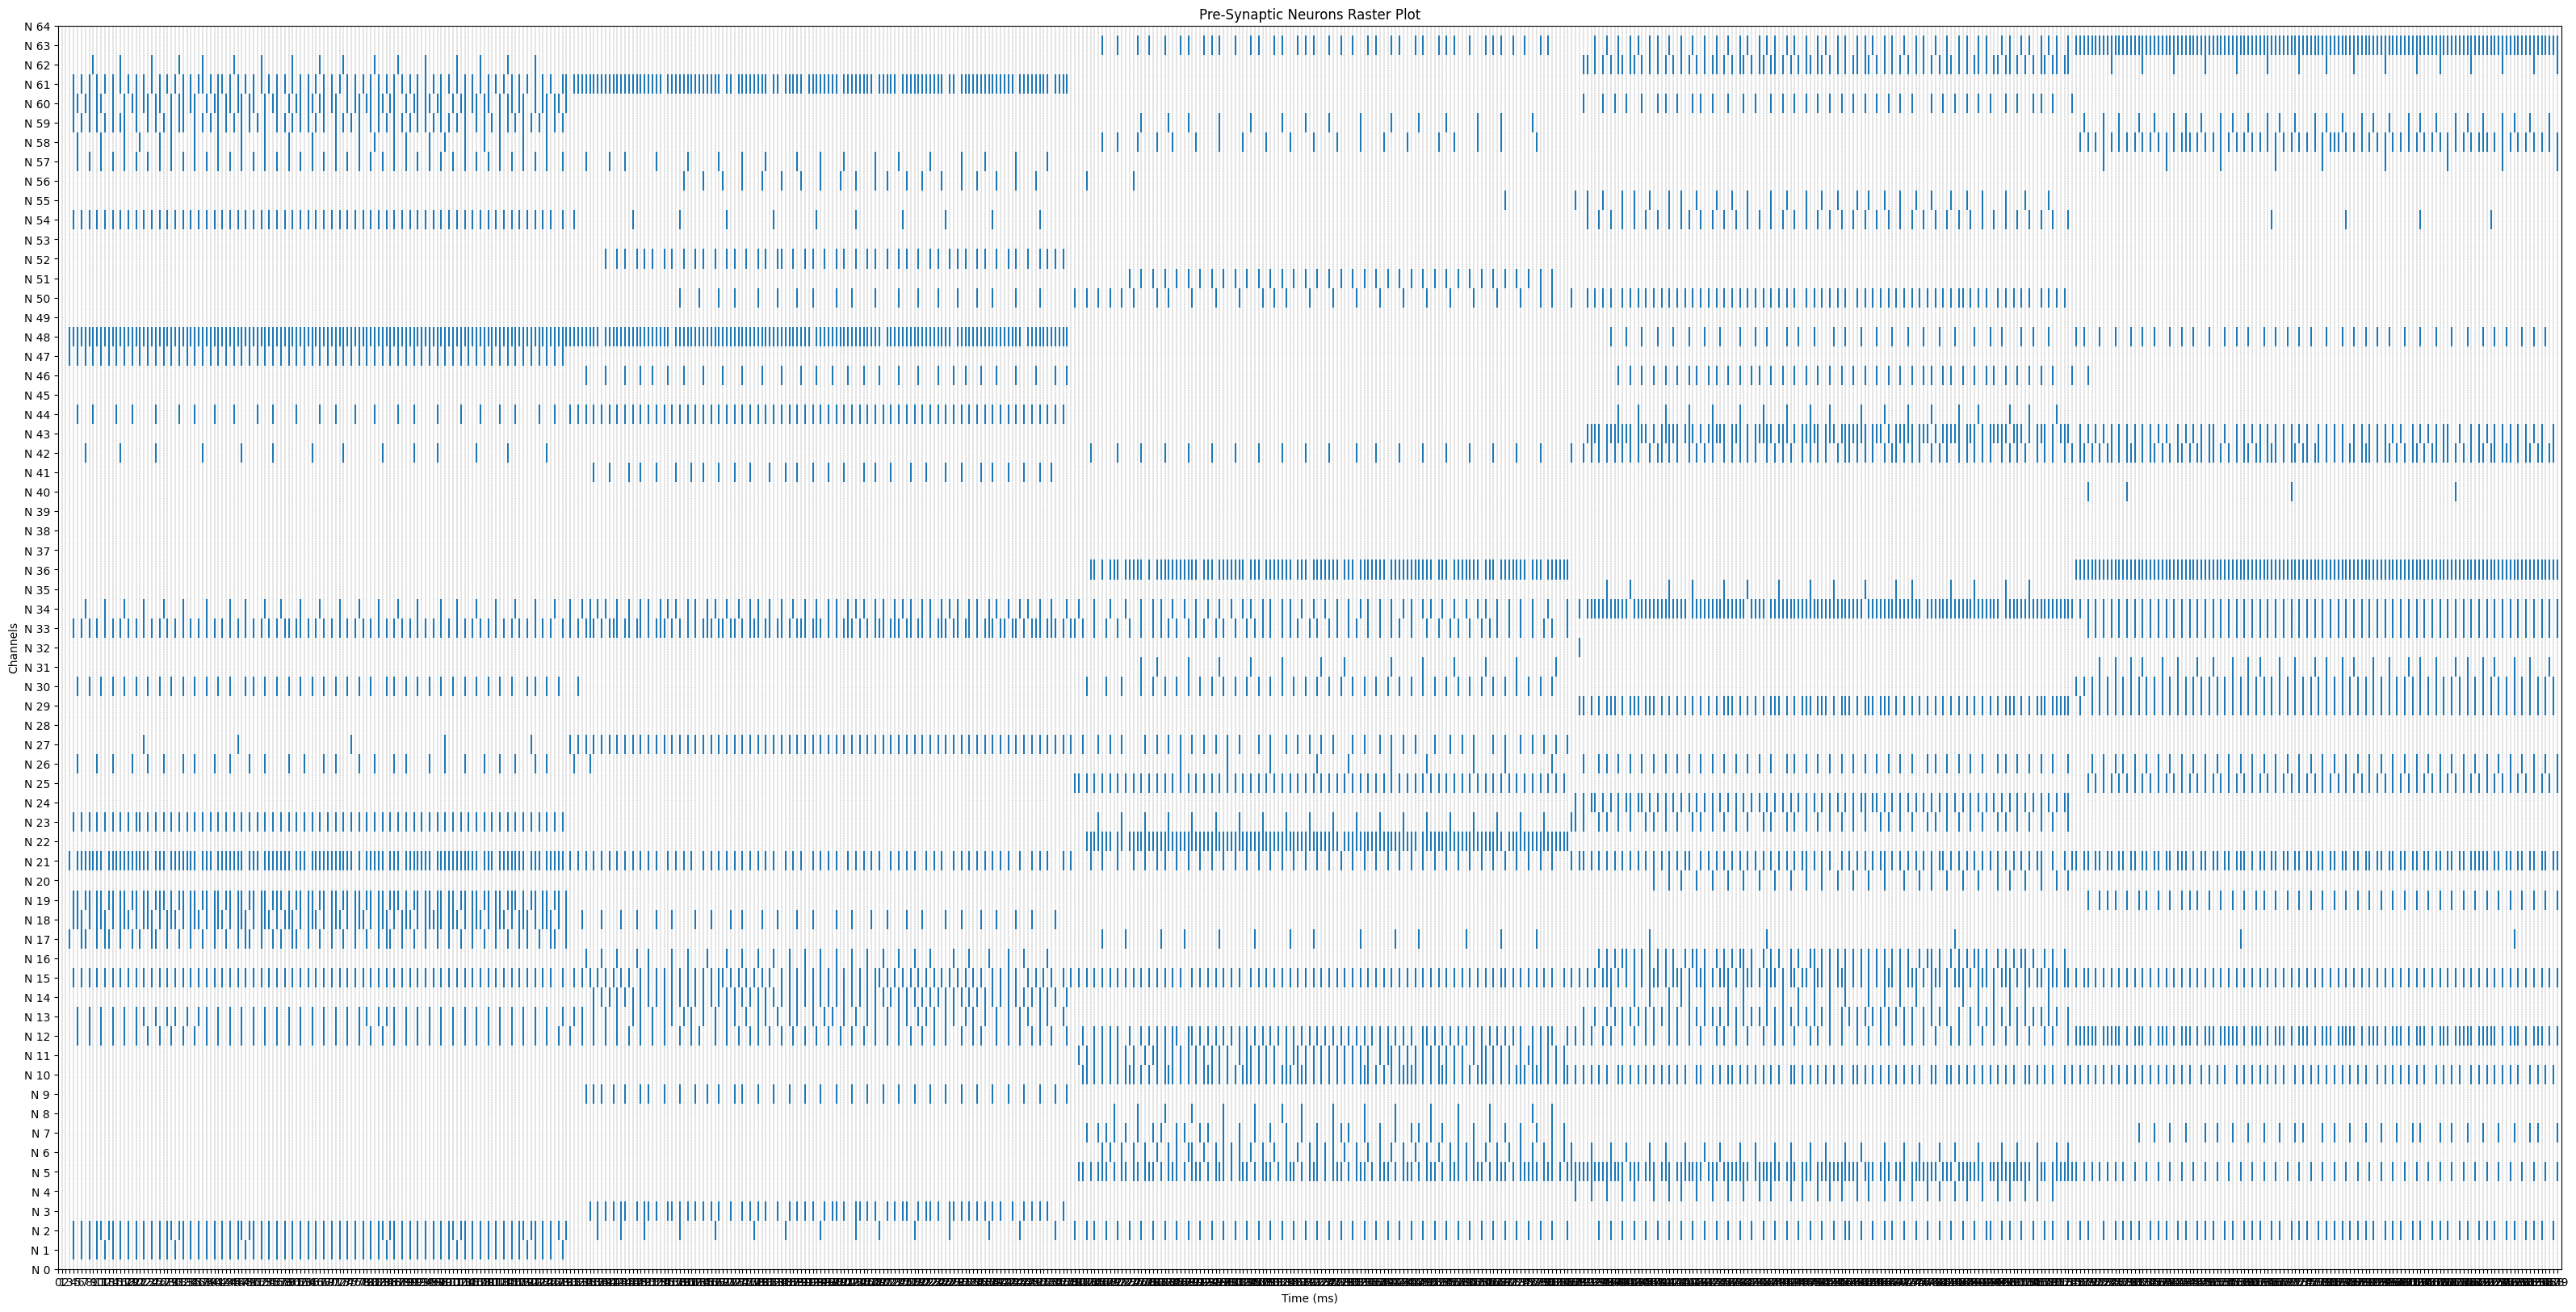

(10, 640)


<Figure size 640x480 with 0 Axes>

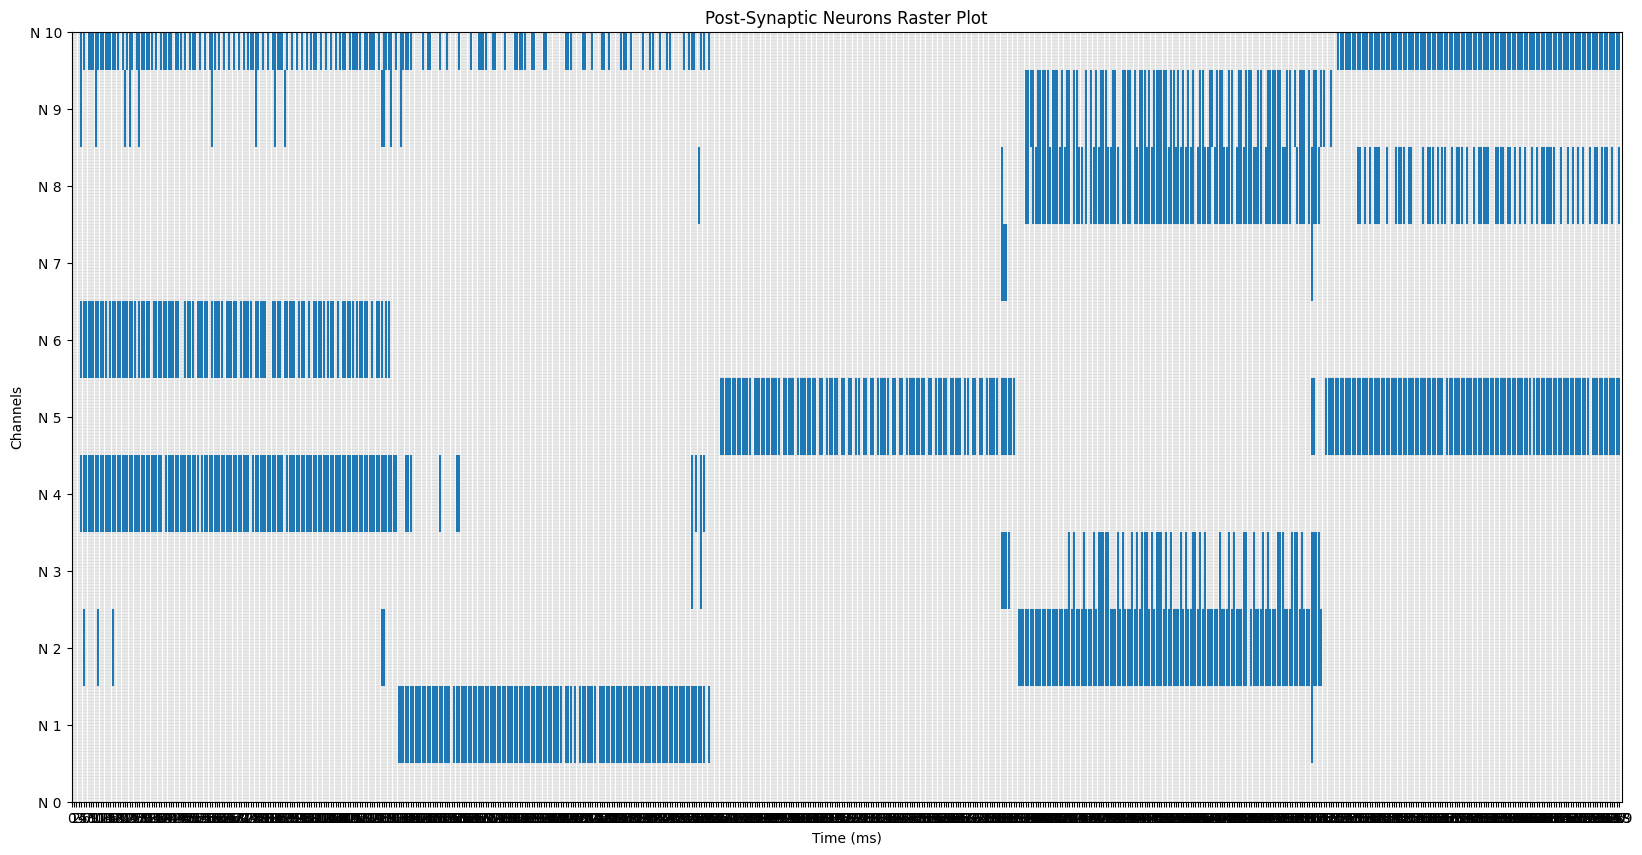

In [15]:
create_raster_plot(pre_spike.T, name='Pre-Synaptic Neurons', figsize=(40, 20))
create_raster_plot(post_spike.T, name='Post-Synaptic Neurons', figsize=(20, 10))

> **Important Note**:
>
> The classifier is a simple feed-forward model using pre-trained network 
> parameters (weights and biases). It illustrates how to build, compile and 
> run a functional model in Lava. Please refer to 
> [Lava-DL](https://github.com/lava-nc/lava-dl) to understand how to train 
> deep networks with Lava.

## How to learn more?

#### Follow the links below for deep-dive tutorials on the concepts in this tutorial:
- [Processes](../in_depth/tutorial02_processes.ipynb "Tutorial on Processes")
- [ProcessModel](../in_depth/tutorial03_process_models.ipynb "Tutorial on ProcessModels")
- [Execution](../in_depth/tutorial04_execution.ipynb "Tutorial on Executing Processes")
- [SubProcessModels](../in_depth/tutorial06_hierarchical_processes.ipynb) or [Hierarchical Processes](../in_depth/tutorial06_hierarchical_processes.ipynb)
- [RefPorts](../in_depth/tutorial07_remote_memory_access.ipynb)

If you want to find out more about Lava, have a look at the [Lava documentation](https://lava-nc.org/ "Lava Documentation") or dive into the [source code](https://github.com/lava-nc/lava/ "Lava Source Code").

To receive regular updates on the latest developments and releases of the Lava Software Framework please subscribe to the [INRC newsletter](http://eepurl.com/hJCyhb "INRC Newsletter").